In [2]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

pd.set_option('display.max_columns', None)

In [3]:
#Load data and overview
# Change to path locally
steam = pd.read_csv("/Users/joannacalizo/Downloads/Uni/26.2/DATA301/Data301-GP/data/games_march2025_cleaned.csv")
print(steam.shape)


(89618, 47)


In [4]:
#Drop columns not useful for analysis
drop_cols = ['header_image', 'website', 'support_url', 'support_email',
             'metacritic_url', 'screenshots', 'movies', 'packages',
             'detailed_description', 'about_the_game', 'short_description',
             'notes']

steam_eda = steam.drop(columns=drop_cols)

In [5]:
#parse strings
def parse_py_list(x):
    if pd.isna(x):
        return []
    try:
        return ast.literal_eval(x)
    except (ValueError, SyntaxError):
        return []

steam_eda['genres_list'] = steam_eda['genres'].apply(parse_py_list)
steam_eda['categories_list'] = steam_eda['categories'].apply(parse_py_list)
steam_eda['developers_list'] = steam_eda['developers'].apply(parse_py_list)
steam_eda['publishers_list'] = steam_eda['publishers'].apply(parse_py_list)

steam_eda['n_genres'] = steam_eda['genres_list'].apply(len)
steam_eda['n_categories'] = steam_eda['categories_list'].apply(len)

# First/primary genre, useful for simple grouping
steam_eda['primary_genre'] = steam_eda['genres_list'].apply(lambda x: x[0] if len(x) > 0 else np.nan)

# estimated_owners: "100000000 - 200000000" -> numeric midpoint
owners_split = steam_eda['estimated_owners'].str.split(' - ', expand=True)
steam_eda['owners_low'] = pd.to_numeric(owners_split[0], errors='coerce')
steam_eda['owners_high'] = pd.to_numeric(owners_split[1], errors='coerce')
steam_eda['owners_mid'] = (steam_eda['owners_low'] + steam_eda['owners_high']) / 2

In [6]:
#Missing data
missing_summary = (
    steam_eda.isna().sum()
    .reset_index()
    .rename(columns={'index': 'column', 0: 'n_missing'})
)
missing_summary['pct_missing'] = round(missing_summary['n_missing'] / len(steam_eda) * 100, 2)
missing_summary = missing_summary[missing_summary['n_missing'] > 0].sort_values('n_missing', ascending=False)

missing_summary

,column,n_missing,pct_missing
20,score_rank,89579,99.96
6,reviews,79217,88.39
41,primary_genre,212,0.24


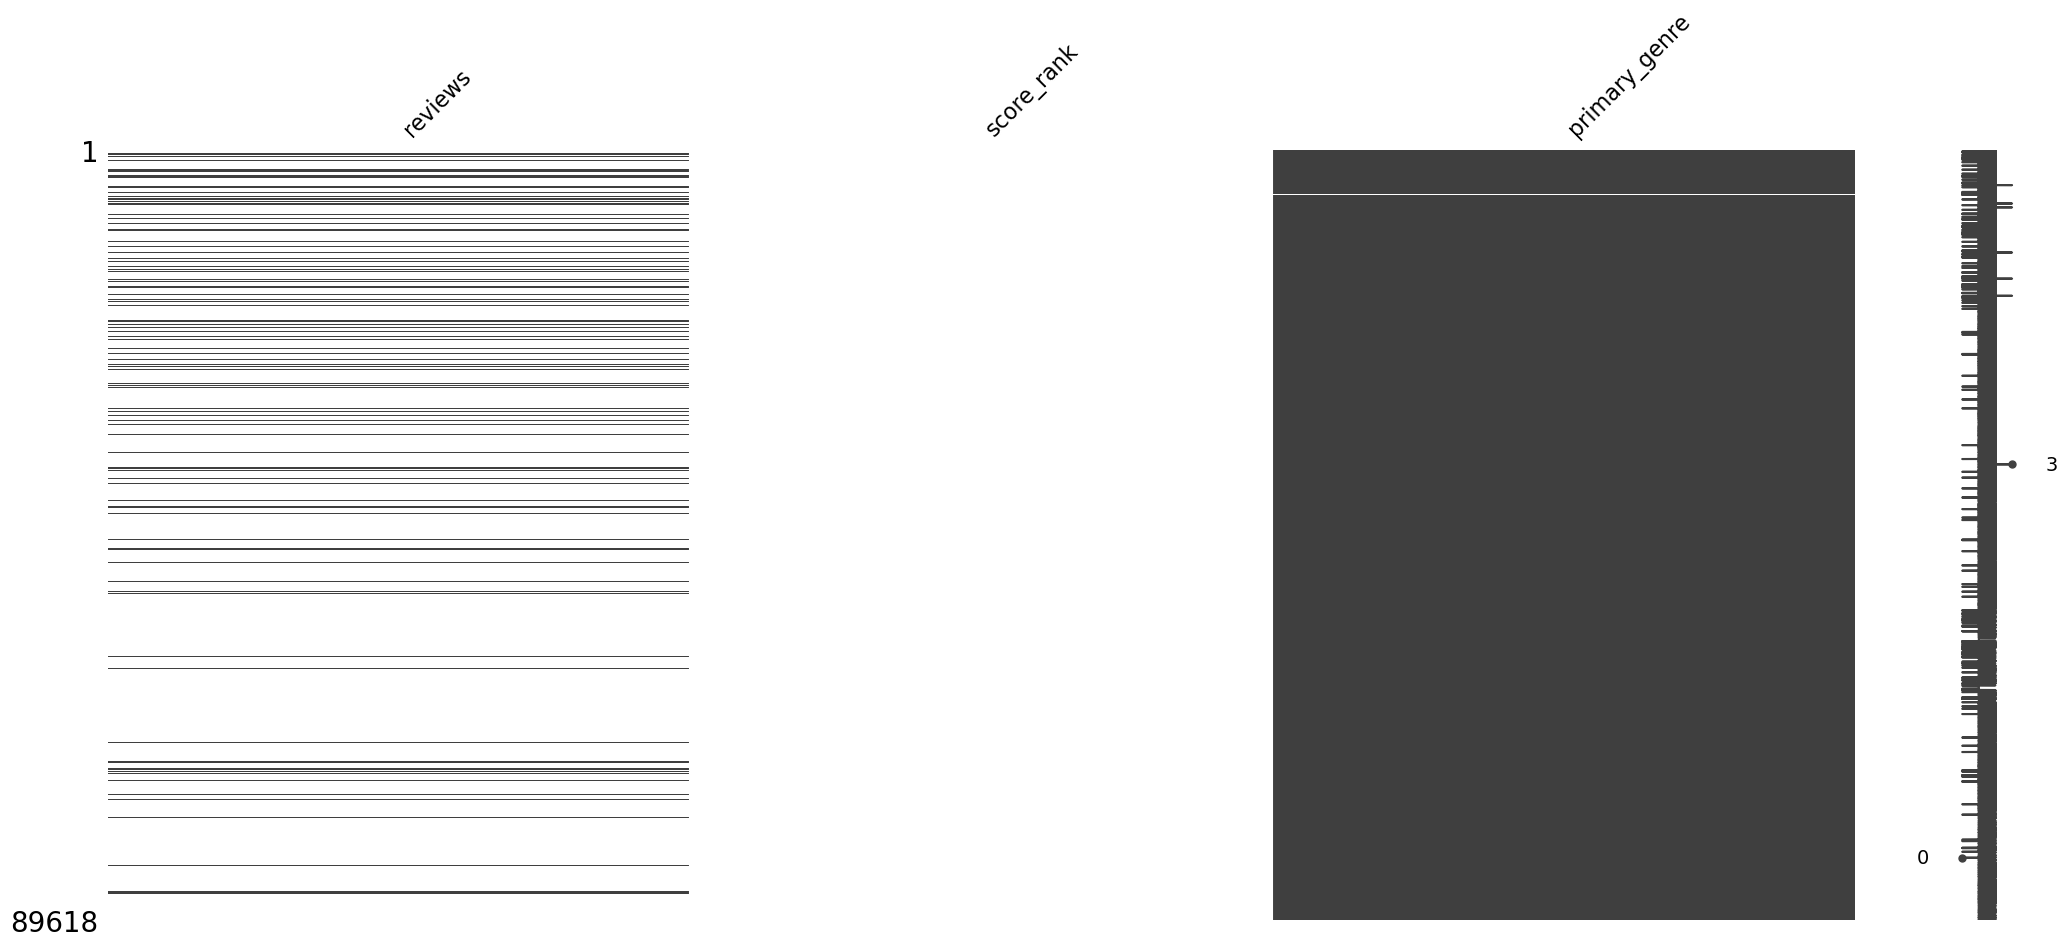

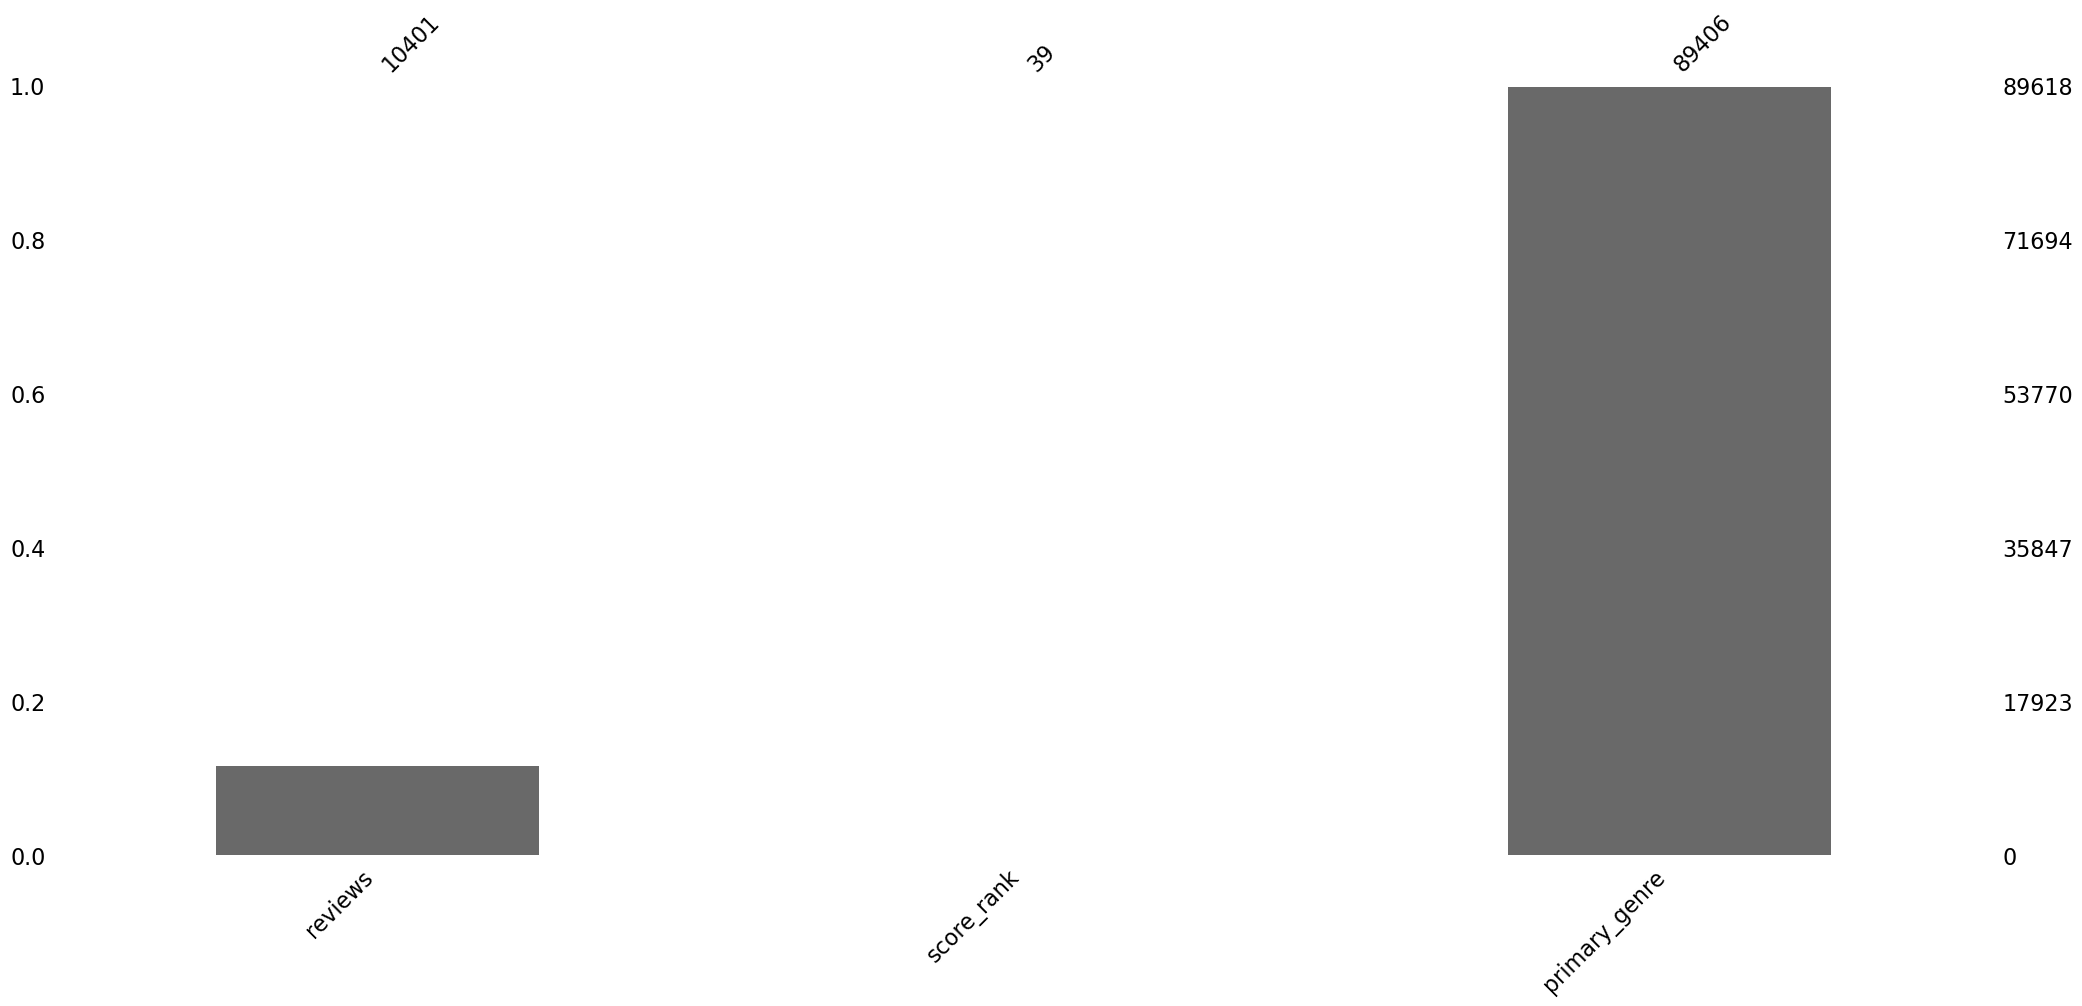

In [7]:
cols_with_na = steam_eda.columns[steam_eda.isna().any()].tolist()

msno.matrix(steam_eda[cols_with_na])
plt.show()

msno.bar(steam_eda[cols_with_na])
plt.show()

In [8]:
#Duplicate rows
dupe_mask = steam['appid'].duplicated(keep=False)
duplicates = steam[dupe_mask].sort_values('appid')

duplicates

,appid,name,release_date,required_age,price,dlc_count,detailed_description,about_the_game,short_description,reviews,header_image,website,support_url,support_email,windows,mac,linux,metacritic_score,metacritic_url,achievements,recommendations,notes,supported_languages,full_audio_languages,packages,developers,publishers,categories,genres,screenshots,movies,user_score,score_rank,positive,negative,estimated_owners,average_playtime_forever,average_playtime_2weeks,median_playtime_forever,median_playtime_2weeks,discount,peak_ccu,tags,pct_pos_total,num_reviews_total,pct_pos_recent,num_reviews_recent


Distributions of success outcome variables (Average play time and Positive reviews)

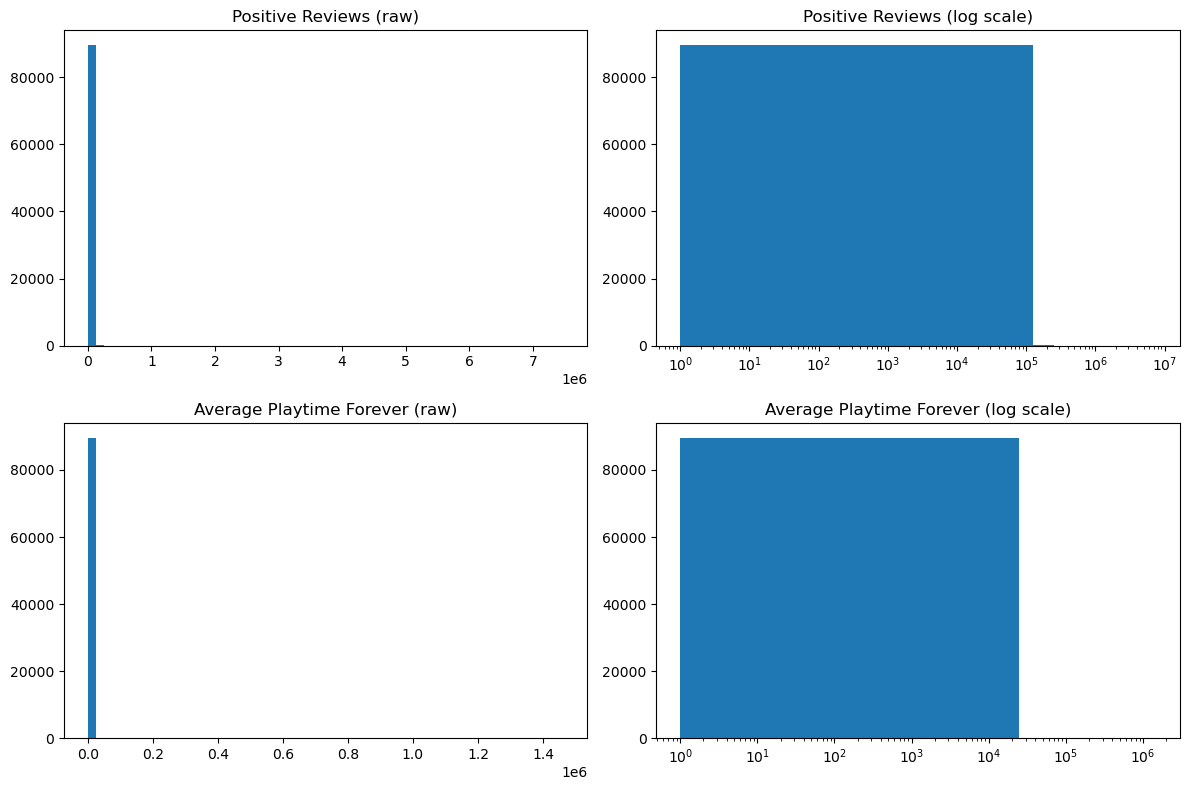

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].hist(steam_eda['positive'], bins=60)
axes[0, 0].set_title('Positive Reviews (raw)')

axes[0, 1].hist(steam_eda['positive'] + 1, bins=60)
axes[0, 1].set_xscale('log')
axes[0, 1].set_title('Positive Reviews (log scale)')

axes[1, 0].hist(steam_eda['average_playtime_forever'], bins=60)
axes[1, 0].set_title('Average Playtime Forever (raw)')

axes[1, 1].hist(steam_eda['average_playtime_forever'] + 1, bins=60)
axes[1, 1].set_xscale('log')
axes[1, 1].set_title('Average Playtime Forever (log scale)')

plt.tight_layout()
plt.show()

In [10]:
steam_eda[['positive', 'negative', 'pct_pos_total', 'average_playtime_forever']].describe()

,positive,negative,pct_pos_total,average_playtime_forever
count,8.961800e+04,8.961800e+04,89618.000000,8.961800e+04
mean,1.269896e+03,2.098026e+02,45.352418,1.149119e+02
std,3.181441e+04,6.114314e+03,40.685695,6.814748e+03
min,0.000000e+00,0.000000e+00,-1.000000,0.000000e+00
25%,1.000000e+00,0.000000e+00,-1.000000,0.000000e+00
50%,1.000000e+01,2.000000e+00,60.000000,0.000000e+00
75%,5.800000e+01,1.700000e+01,84.000000,0.000000e+00
max,7.480813e+06,1.135108e+06,100.000000,1.462997e+06


How many games have no success signal

In [11]:
print("Games with 0 positive reviews:", (steam_eda['positive'] == 0).sum())
print("Games with 0 average playtime forever:", (steam_eda['average_playtime_forever'] == 0).sum())
print("Games with both 0:", ((steam_eda['positive'] == 0) & (steam_eda['average_playtime_forever'] == 0)).sum())

Games with 0 positive reviews: 19425
Games with 0 average playtime forever: 81608
Games with both 0: 19231


Relationship between average play time and positive reviews

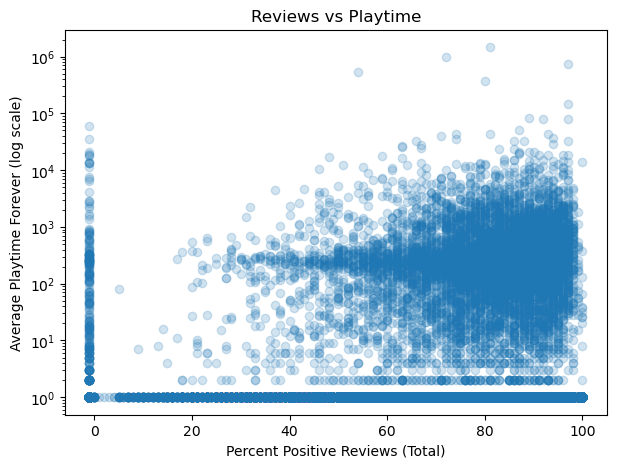

,pct_pos_total,average_playtime_forever,positive
pct_pos_total,1.000000,0.013516,0.039817
average_playtime_forever,0.013516,1.000000,0.031902
positive,0.039817,0.031902,1.000000


In [13]:
plt.figure(figsize=(7, 5))
plt.scatter(steam_eda['pct_pos_total'], steam_eda['average_playtime_forever'] + 1, alpha=0.2)
plt.yscale('log')
plt.xlabel('Percent Positive Reviews (Total)')
plt.ylabel('Average Playtime Forever (log scale)')
plt.title('Reviews vs Playtime')
plt.show()

steam_eda[['pct_pos_total', 'average_playtime_forever', 'positive']].corr()